Scraping data for AAPL from Yahoo Finance...
Calculating Bollinger Bands for AAPL...
Adding Close > Open column for AAPL...
Calculating Pivot Points for AAPL...
Calculating Buying Indicator v2 for AAPL...
         Date    Open    High     Low   Close  Adj Close    Volume      SMA  \
29 2022-02-14  167.37  169.58  166.56  168.88     166.19  86185500  168.826   

        STD  Upper Band  Lower Band Closing Candle  Pivot Point     R1  \
29  5.79097  180.407939  157.244061          green       169.92  171.8   

        S1      R2      S2  Close_Open_Diff_v2  
29  166.76  174.96  164.88                 NaN  
         Date    Open    High     Low   Close  Adj Close     Volume     SMA  \
52 2022-03-18  160.51  164.48  159.76  163.98     161.37  123511700  161.32   

         STD  Upper Band  Lower Band Closing Candle  Pivot Point      R1  \
52  4.416977  170.153954  152.486046          green       159.75  161.87   

       S1      R2      S2  Close_Open_Diff_v2  
52  158.5  163.12  156.38    

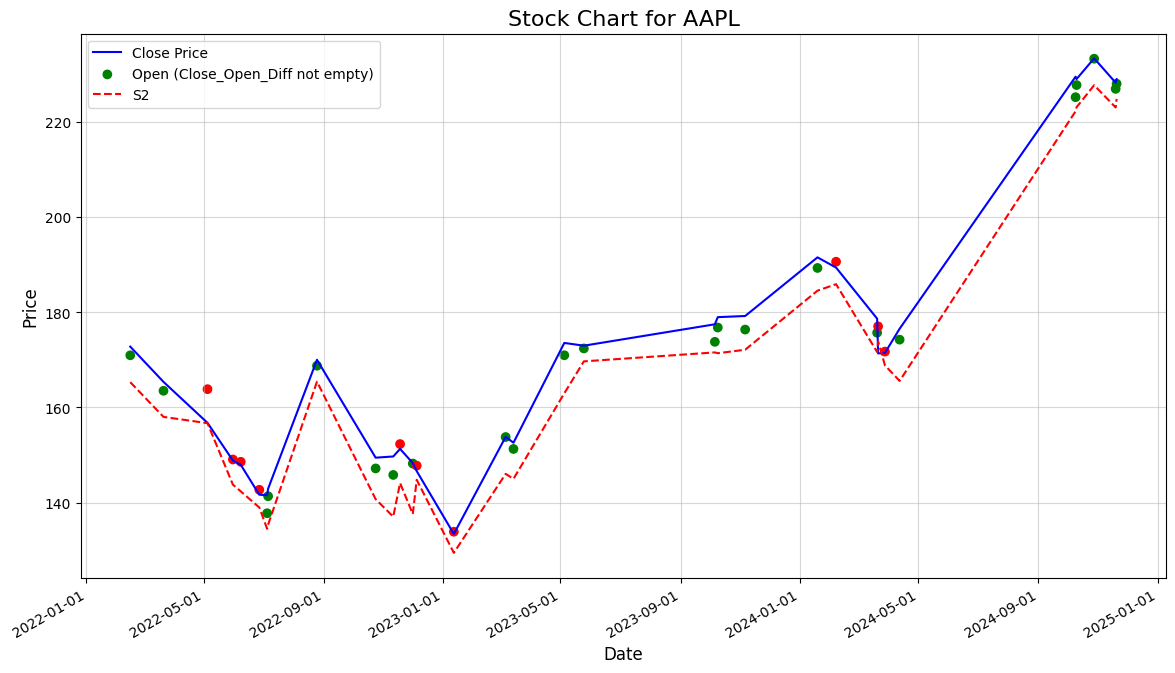

Scraping data for META from Yahoo Finance...
Calculating Bollinger Bands for META...
Adding Close > Open column for META...
Calculating Pivot Points for META...
Calculating Buying Indicator v2 for META...
         Date    Open    High     Low  Close  Adj Close    Volume     SMA  \
20 2022-02-01  314.56  319.66  312.12  319.0     317.79  18023800  318.43   

          STD  Upper Band  Lower Band Closing Candle  Pivot Point      R1  \
20  13.868774  346.167549  290.692451          green       308.79  318.26   

        S1      R2      S2  Close_Open_Diff_v2  
20  303.79  323.26  294.32                 NaN  
         Date   Open    High     Low   Close  Adj Close    Volume       SMA  \
50 2022-03-16  194.7  203.73  194.52  203.63     202.86  40640300  200.8025   

         STD  Upper Band  Lower Band Closing Candle  Pivot Point          R1  \
50  8.664155   218.13081   183.47419          green   190.073333  194.236667   

            S1          R2          S2  Close_Open_Diff_v2  
50  18

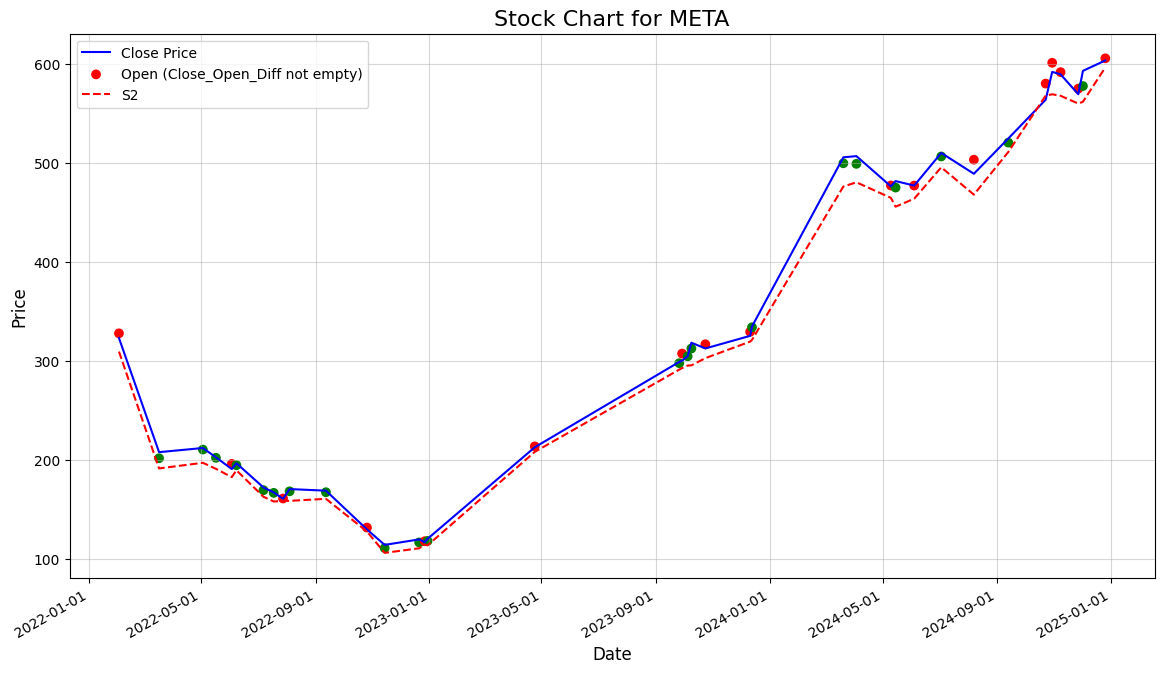

Scraping data for NVDA from Yahoo Finance...
Calculating Bollinger Bands for NVDA...
Adding Close > Open column for NVDA...
Calculating Pivot Points for NVDA...
Calculating Buying Indicator v2 for NVDA...
         Date   Open   High    Low  Close  Adj Close     Volume      SMA  \
25 2022-02-08  24.36  25.23  23.98  25.11      25.07  410359000  24.6775   

        STD  Upper Band  Lower Band Closing Candle  Pivot Point         R1  \
25  1.72085     28.1192     21.2358          green    24.703333  25.206667   

           S1         R2         S2  Close_Open_Diff_v2  
25  24.226667  25.683333  23.723333                 NaN  
         Date   Open   High    Low  Close  Adj Close     Volume      SMA  \
29 2022-02-14  23.93  24.88  23.75  24.27      24.23  440424000  24.2475   

        STD  Upper Band  Lower Band Closing Candle  Pivot Point         R1  \
29  1.23556   26.718621   21.776379          green    24.623333  25.476667   

           S1         R2         S2  Close_Open_Diff_v2  
2

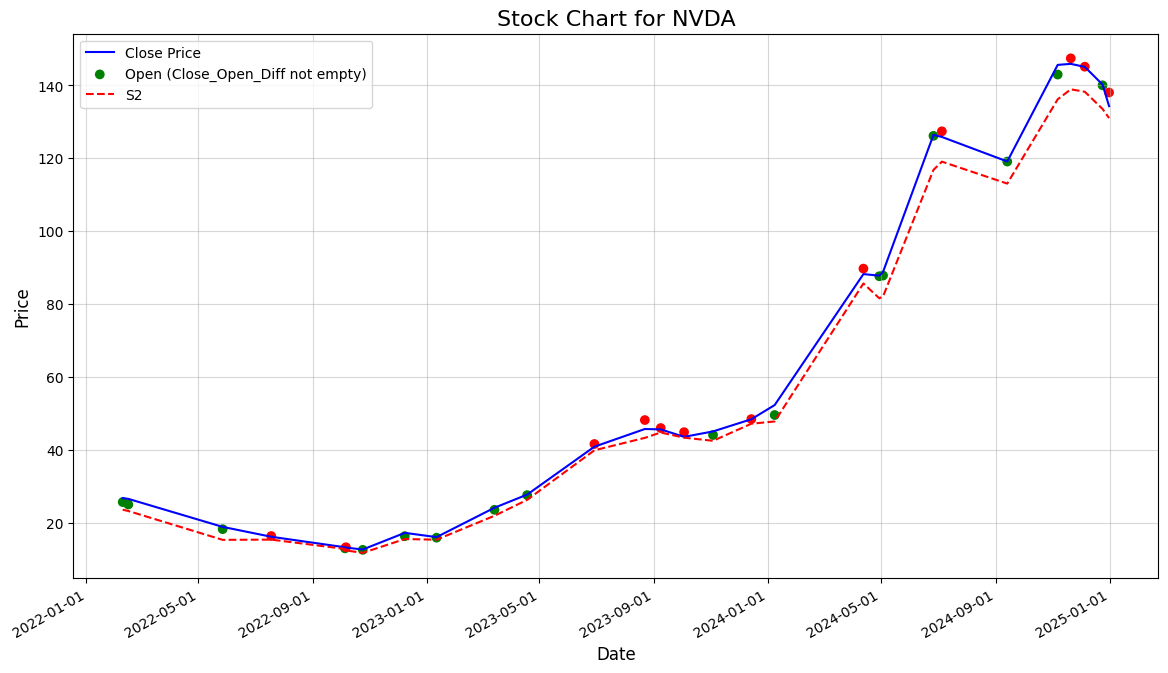

In [15]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import mplfinance as mpf

# Step 1: Scrape Historical Data
def scrape_yahoo_finance_data(ticker):
    url = "https://finance.yahoo.com/quote/" + ticker + "/history/?period1=1641168000&period2=1735862400"
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36"
    }
    
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, 'html.parser')

    # Locate the table
    table = soup.find("table")
    if not table:
        print("Failed to find the data table. Yahoo Finance may have changed its structure.")
        return None

    # Extract table rows
    rows = table.find_all("tr")

    data = []
    for row in rows[1:]:
        cols = row.find_all("td")
        if len(cols) < 7:
            continue
        date = cols[0].text.strip()
        try:
            open_price = float(cols[1].text.replace(",", ""))
            high = float(cols[2].text.replace(",", ""))
            low = float(cols[3].text.replace(",", ""))
            close = float(cols[4].text.replace(",", ""))
            adj_close = float(cols[5].text.replace(",", ""))
            volume = int(cols[6].text.replace(",", ""))
        except ValueError:
            continue  # Skip invalid rows
        data.append([date, open_price, high, low, close, adj_close, volume])

    # Create a DataFrame
    df = pd.DataFrame(data, columns=["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume"])
    df["Date"] = pd.to_datetime(df["Date"])
    df.sort_values("Date", inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df

# Step 2: Calculate Bollinger Bands
def calculate_bollinger_bands(df, window=20, num_std_dev=2):
    df["SMA"] = df["Close"].rolling(window=window).mean()
    df["STD"] = df["Close"].rolling(window=window).std()
    df["Upper Band"] = df["SMA"] + (num_std_dev * df["STD"])
    df["Lower Band"] = df["SMA"] - (num_std_dev * df["STD"])
    return df

# Step 3: Add Close > Open Column
def add_close_greater_than_open_column(df):
    df['Closing Candle'] = np.where(df['Close'] > df['Open'], 'green', 'red')
    return df

# Step 5: Calculate Pivot Points
def calculate_pivot_points(df):
    # Calculate Pivot Point based on the previous day's High, Low, and Close
    df["Pivot Point"] = (df["High"].shift(1) + df["Low"].shift(1) + df["Close"].shift(1)) / 3
    
    # Calculate R1, S1, R2, and S2 based on the previous day's Pivot Point, High, and Low
    df["R1"] = (2 * df["Pivot Point"]) - df["Low"].shift(1)
    df["S1"] = (2 * df["Pivot Point"]) - df["High"].shift(1)
    df["R2"] = df["Pivot Point"] + (df["High"].shift(1) - df["Low"].shift(1))
    df["S2"] = df["Pivot Point"] - (df["High"].shift(1) - df["Low"].shift(1))
    
    return df

# Step 6: Calculate Buying Indicator
# def buy_indicator(df):
#     # Add a new column 'Close_Open_Diff' to store the difference between 'Close' and 'Open'
#     df['Close_Open_Diff'] = np.nan

#     # Loop through the DataFrame and mark rows where the previous 3 closing candle values are red
#     for index, row in df.iterrows():
#         if index >= 3:
#             previous_3_rows = df.iloc[index-3:index]
#             if all(previous_3_rows['Closing Candle'] == 'red'):
#                 df.at[index, 'Close_Open_Diff'] = row['Close'] - row['Open']
#     return df.dropna(subset=['Close_Open_Diff'])

def buy_indicator_v2(df):
    # Add a new column 'Close_Open_Diff_v2' to store the difference between 'Close' and 'Open'
    df['Close_Open_Diff_v2'] = np.nan

    # Loop through the DataFrame and mark rows where the previous 3 closing candle values are red
    for index, row in df.iterrows():
        if index >= 1:
            previous_1_rows = df.iloc[index-1:index]
            if (previous_1_rows['Open'] < previous_1_rows['SMA']).all() and (previous_1_rows['Close'] > previous_1_rows['SMA']).all():
                print(previous_1_rows)
                df.at[index, 'Close_Open_Diff_v2'] = row['Close'] - row['Open']
    return df.dropna(subset=['Close_Open_Diff_v2'])

    
# Step 7: Plot Stock Chart with Bollinger Bands and Pivot Points
def plot_stock_chart(df, ticker):
    # Filter the DataFrame to get the rows where 'Close_Open_Diff' is not NaN
    # print(df.columns)
    df_with_diff = df.dropna(subset=['Close_Open_Diff_v2'])
    # # Ensure the DataFrame has a DateTime index
    # df['Date'] = pd.to_datetime(df['Date'])
    # df.set_index('Date', inplace=True)

    # # Select the columns needed for the candlestick chart
    # df_candlestick = df[['Open', 'High', 'Low', 'Close', 'Volume']]

    # # Print the columns of the DataFrame
    # print("Columns:", df.columns)

    # # Print the first few rows of the DataFrame
    # print("First few rows:\n", df.head())

    # # Print the index of the DataFrame
    # print("Index:", df_candlestick.index)

    # # Plot the candlestick chart
    # mpf.plot(df_candlestick, type='candle', style='charles', title='Candlestick Chart', ylabel='Price', volume=True, warn_too_much_data=1000000000)
    
    plt.figure(figsize=(14, 8))

    # Plot Closing Prices
    plt.plot(df["Date"], df["Close"], label="Close Price", color="blue", linewidth=1.5)

    # Plot Open values with conditional coloring based on Close_Open_Diff
    # colors = np.where(df_with_diff["Close_Open_Diff"] > 0, 'green', 'red')
    # plt.scatter(df_with_diff["Date"], df_with_diff["Open"], color=colors, label='Open (Close_Open_Diff not empty)')

    colors = np.where(df_with_diff["Close_Open_Diff_v2"] > 0, 'green', 'red')
    plt.scatter(df_with_diff["Date"], df_with_diff["Open"], color=colors, label='Open (Close_Open_Diff not empty)')

    # Plot Bollinger Bands
    # plt.plot(df["Date"], df["Upper Band"], label="Upper Band", color="orange", linestyle="--")
    # plt.plot(df["Date"], df["Lower Band"], label="Lower Band", color="orange", linestyle="--")
    # plt.fill_between(df["Date"], df["Lower Band"], df["Upper Band"], color="orange", alpha=0.1)

    # Plot Pivot Points
    # plt.plot(df["Date"], df["Pivot Point"], label="Pivot Point", color="purple", linestyle="--")
    # plt.plot(df["Date"], df["R1"], label="R1", color="green", linestyle=":")
    # plt.plot(df["Date"], df["S1"], label="S1", color="red", linestyle=":")
    # plt.plot(df["Date"], df["R2"], label="R2", color="green", linestyle="--")
    plt.plot(df["Date"], df["S2"], label="S2", color="red", linestyle="--")

    # Chart Formatting
    plt.title("Stock Chart for " + ticker, fontsize=16)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Price", fontsize=12)
    plt.legend(loc="upper left", fontsize=10)
    plt.grid(alpha=0.5)

    # Formatting date on x-axis
    plt.gca().xaxis.set_major_formatter(DateFormatter("%Y-%m-%d"))
    plt.gcf().autofmt_xdate()

    # Show the chart
    plt.show()

# Step 7: Save to CSV
# Function to save DataFrame to CSV
def save_to_csv(df, filename):
    df.to_csv(filename, index=False)
    print(f"Data successfully saved to {filename}")

# Main Function
if __name__ == "__main__":
    tickers = ['AAPL', 'META', 'NVDA']  # List of stock tickers

    for ticker in tickers:
        print(f"Scraping data for {ticker} from Yahoo Finance...")
        historical_data = scrape_yahoo_finance_data(ticker)
        
        if historical_data is not None:
            print(f"Calculating Bollinger Bands for {ticker}...")
            historical_data = calculate_bollinger_bands(historical_data)
            
            print(f"Adding Close > Open column for {ticker}...")
            historical_data = add_close_greater_than_open_column(historical_data)

            print(f"Calculating Pivot Points for {ticker}...")
            historical_data = calculate_pivot_points(historical_data)

            # print(f"Calculating Buying Indicator for {ticker}...")
            # historical_data = buy_indicator(historical_data)

            print(f"Calculating Buying Indicator v2 for {ticker}...")
            historical_data = buy_indicator_v2(historical_data)

            # Print the sum total
            # print(f"Sum total of Close_Open_Diff: {historical_data['Close_Open_Diff'].sum()}")
            print(f"Sum total of Close_Open_Diff V2: {historical_data['Close_Open_Diff_v2'].sum()}")
            
            print(f"Saving {ticker} data to CSV...")
            save_to_csv(historical_data, f"{ticker}_data.csv")

            print(f"Plotting stock chart for {ticker}...")
            plot_stock_chart(historical_data, ticker)
        else:
            print(f"Failed to scrape data for {ticker}.")




